# 08 — Ablacje i istotność statystyczna

Łączy **metryki autorskie** (Hit@5, MRR, Chunk Hit@5 z offline) z **DeepEval** (Faithfulness, Answer Relevancy, Contextual Recall/Precision, Answer Correctness).

| Część | Cel |
|-------|-----|
| **A. Ablacje** | Δ średnich przy kolejnych zmianach pipeline (W1→…→W5), w tym **W3 vs W4** (GIN↔BM25) |
| **B. Istotność** | Wilcoxon signed-rank (pary pytań), H₀, α=0.05 |

Bez latency — to jest w `07_latency_analysis.ipynb`. Podgląd średnich DeepEval — `05_deepeval_analysis.ipynb`.

**Etykiety wariantów**

| Kod | Nazwa |
|-----|--------|
| W1 | Naive RAG |
| W2 | Parent-Child Chunking |
| W3 | Hybrid RAG (GIN) |
| W4 | Hybrid RAG (BM25) |
| W5 | W4 + Self-RAG |


## 0. Dane i tabela bazowa


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display
from scipy import stats

EVAL = Path.cwd() if (Path.cwd() / "output").exists() else Path.cwd() / "evaluation"
load_dotenv(EVAL / ".env")
load_dotenv(EVAL / ".env.example")

BATCH_ID = os.getenv("EVAL_BATCH_ID", "eval-main")
DE = EVAL / "output" / "deepeval"
OFF = EVAL / "output" / "analysis"
OUT = DE / "ablation"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

VARIANT_ORDER = [
    "baseline0", "baseline1", "eksperyment1-gin", "eksperyment1-bm25", "eksperyment2",
]
LABELS = {
    "baseline0": "W1",
    "baseline1": "W2",
    "eksperyment1-gin": "W3",
    "eksperyment1-bm25": "W4",
    "eksperyment2": "W5",
}
NAMES = {
    "baseline0": "W1: Naive RAG",
    "baseline1": "W2: Parent-Child Chunking",
    "eksperyment1-gin": "W3: Hybrid RAG (GIN)",
    "eksperyment1-bm25": "W4: Hybrid RAG (BM25)",
    "eksperyment2": "W5: W4 + Self-RAG",
}

# Offline (n≈215) + DeepEval cohort
OFF_METRICS = ["hit_at_5", "mrr", "chunk_hit5", "idk_rate"]
DE_METRICS = [
    "faithfulness",
    "answer_relevancy",
    "contextual_recall",
    "contextual_precision",
    "answer_correctness",
]
METRIC_LABEL = {
    "hit_at_5": "Hit@5",
    "mrr": "MRR",
    "chunk_hit5": "Chunk Hit@5",
    "idk_rate": "IDK",
    "faithfulness": "Faithfulness",
    "answer_relevancy": "Answer Relevancy",
    "contextual_recall": "Contextual Recall",
    "contextual_precision": "Contextual Precision",
    "answer_correctness": "Answer Correctness",
}

per_q = pd.read_csv(DE / f"deepeval_per_question_{BATCH_ID}.csv")
off = pd.read_csv(OFF / "summary_by_variant.csv")
per_q["label"] = per_q["variant"].map(LABELS)
per_q["variant"] = pd.Categorical(per_q["variant"], categories=VARIANT_ORDER, ordered=True)

# Średnie DeepEval z per_q; offline Hit@5/MRR/Chunk z summary (pełna kohorta)
rows = []
for v in VARIANT_ORDER:
    g = per_q[per_q["variant"] == v]
    o = off.loc[off["variant"] == v].iloc[0]
    row = {
        "variant": v,
        "label": LABELS[v],
        "name": NAMES[v],
        "n_offline": int(o["n"]),
        "n_deepeval": len(g),
        "errors": int(g["deepeval_error"].notna().sum()),
        "hit_at_5": float(o["hit_at_5"]),
        "mrr": float(o["mrr"]),
        "chunk_hit5": float(o["chunk_hit5"]),
        "idk_rate": float(o["idk_rate"]),
    }
    for m in DE_METRICS:
        row[m] = float(pd.to_numeric(g[m], errors="coerce").mean())
    rows.append(row)

base = pd.DataFrame(rows)
base.to_csv(OUT / f"base_means_{BATCH_ID}.csv", index=False)

show_cols = ["label", "name", "n_offline", "n_deepeval", "errors"] + OFF_METRICS + DE_METRICS
display(
    base[show_cols]
    .rename(columns={"label": "W", "name": "Wariant", **METRIC_LABEL})
    .round(3)
)
print(f"DeepEval per_q={len(per_q)} | errors={int(per_q['deepeval_error'].notna().sum())}")


,W,Wariant,n_offline,n_deepeval,errors,Hit@5,MRR,Chunk Hit@5,IDK,Faithfulness,Answer Relevancy,Contextual Recall,Contextual Precision,Answer Correctness
0,W1,W1: Naive RAG,215,207,9,0.712,0.677,0.000,0.205,0.825,0.860,0.741,0.683,0.513
1,W2,W2: Parent-Child Chunking,215,206,6,0.698,0.672,0.595,0.200,0.843,0.855,0.678,0.695,0.545
2,W3,W3: Hybrid RAG (GIN),215,193,15,0.837,0.832,0.702,0.102,0.789,0.891,0.873,0.886,0.683
3,W4,W4: Hybrid RAG (BM25),215,198,7,0.860,0.850,0.693,0.093,0.803,0.907,0.861,0.881,0.676
4,W5,W5: W4 + Self-RAG,215,196,10,0.851,0.841,0.698,0.093,0.820,0.905,0.867,0.878,0.682


DeepEval per_q=1000 | errors=47


# Część A — Ablacje

Każdy krok zmienia **jeden** (lub spójny) element pipeline. Δ = średnia(B) − średnia(A); dodatnie = poprawa jakości (dla IDK: ujemne = mniej odmów).

| Krok | Co zmieniamy | Pytanie badawcze |
|------|----------------|------------------|
| **W1 → W2** | flat chunking → parent–child | Czy sam chunking poprawia retrieval / generację? |
| **W2 → W3** | + hybryda dense+GIN + rerank | Jaki skok daje hybryda z indeksem GIN? |
| **W2 → W4** | + hybryda dense+BM25 + rerank | Jaki skok daje hybryda z indeksem BM25? |
| **W3 → W4** | GIN → BM25 (reszta stała) | Czy zmiana indeksu FTS ma wpływ? |
| **W4 → W5** | + Self-RAG | Czy Self-RAG poprawia jakość generacji? |
| **W1 → W4** | pełna ścieżka (orientacyjnie) | Skumulowany zysk vs Naive RAG |


## A.1 Delty średnich (wszystkie metryki)


In [2]:
idx = base.set_index("variant")

def delta(a: str, b: str, col: str) -> float:
    return float(idx.loc[b, col] - idx.loc[a, col])

ABLATION_PAIRS = [
    ("baseline0", "baseline1", "W1 → W2", "Chunking: flat → parent–child"),
    ("baseline1", "eksperyment1-gin", "W2 → W3", "Hybryda dense+GIN + rerank"),
    ("baseline1", "eksperyment1-bm25", "W2 → W4", "Hybryda dense+BM25 + rerank"),
    ("eksperyment1-gin", "eksperyment1-bm25", "W3 → W4", "Indeks FTS: GIN → BM25"),
    ("eksperyment1-bm25", "eksperyment2", "W4 → W5", "Self-RAG na bazie W4"),
    ("baseline0", "eksperyment1-bm25", "W1 → W4", "Pełna ścieżka vs Naive RAG"),
]

metric_cols = OFF_METRICS + DE_METRICS
abl_rows = []
for a, b, krok, zmiana in ABLATION_PAIRS:
    row = {"krok": krok, "zmiana": zmiana, "a": a, "b": b}
    for m in metric_cols:
        row[f"d_{m}"] = delta(a, b, m)
    abl_rows.append(row)

ablations = pd.DataFrame(abl_rows)
ablations.to_csv(OUT / f"ablation_deltas_{BATCH_ID}.csv", index=False)

abl_show = ablations[["krok", "zmiana"] + [f"d_{m}" for m in metric_cols]].copy()
abl_show.columns = ["Krok", "Zmiana"] + [f"Δ {METRIC_LABEL[m]}" for m in metric_cols]
display(abl_show.round(3))


,Krok,Zmiana,Δ Hit@5,Δ MRR,Δ Chunk Hit@5,Δ IDK,Δ Faithfulness,Δ Answer Relevancy,Δ Contextual Recall,Δ Contextual Precision,Δ Answer Correctness
0,W1 → W2,Chunking: flat → parent–child,-0.014,-0.005,0.595,-0.005,0.017,-0.005,-0.062,0.012,0.031
1,W2 → W3,Hybryda dense+GIN + rerank,0.140,0.160,0.107,-0.098,-0.054,0.036,0.195,0.190,0.138
2,W2 → W4,Hybryda dense+BM25 + rerank,0.163,0.179,0.098,-0.107,-0.040,0.052,0.183,0.186,0.132
3,W3 → W4,Indeks FTS: GIN → BM25,0.023,0.019,-0.009,-0.009,0.014,0.015,-0.013,-0.005,-0.006
4,W4 → W5,Self-RAG na bazie W4,-0.009,-0.009,0.005,0.000,0.018,-0.001,0.006,-0.003,0.006
5,W1 → W4,Pełna ścieżka vs Naive RAG,0.149,0.173,0.693,-0.112,-0.023,0.046,0.120,0.198,0.163


In [9]:
# Ta sama tabela Δ, ale: wiersze = metryki, kolumny = kroki ablacji
abl_T = (
    ablations.set_index("krok")[[f"d_{m}" for m in metric_cols]]
    .T
)
abl_T.index = [f"Δ {METRIC_LABEL[m]}" for m in metric_cols]
abl_T.columns.name = None
abl_T.index.name = "Metryka"

display(abl_T.round(3))
abl_T.round(4).to_csv(OUT / f"ablation_deltas_T_{BATCH_ID}.csv")


,W1 → W2,W2 → W3,W2 → W4,W3 → W4,W4 → W5,W1 → W4
Metryka,,,,,,
Δ Hit@5,-0.014,0.140,0.163,0.023,-0.009,0.149
Δ MRR,-0.005,0.160,0.179,0.019,-0.009,0.173
Δ Chunk Hit@5,0.595,0.107,0.098,-0.009,0.005,0.693
Δ IDK,-0.005,-0.098,-0.107,-0.009,0.000,-0.112
Δ Faithfulness,0.017,-0.054,-0.040,0.014,0.018,-0.023
Δ Answer Relevancy,-0.005,0.036,0.052,0.015,-0.001,0.046
Δ Contextual Recall,-0.062,0.195,0.183,-0.013,0.006,0.120
Δ Contextual Precision,0.012,0.190,0.186,-0.005,-0.003,0.198
Δ Answer Correctness,0.031,0.138,0.132,-0.006,0.006,0.163


## A.2 Wykres Δ — kluczowe metryki


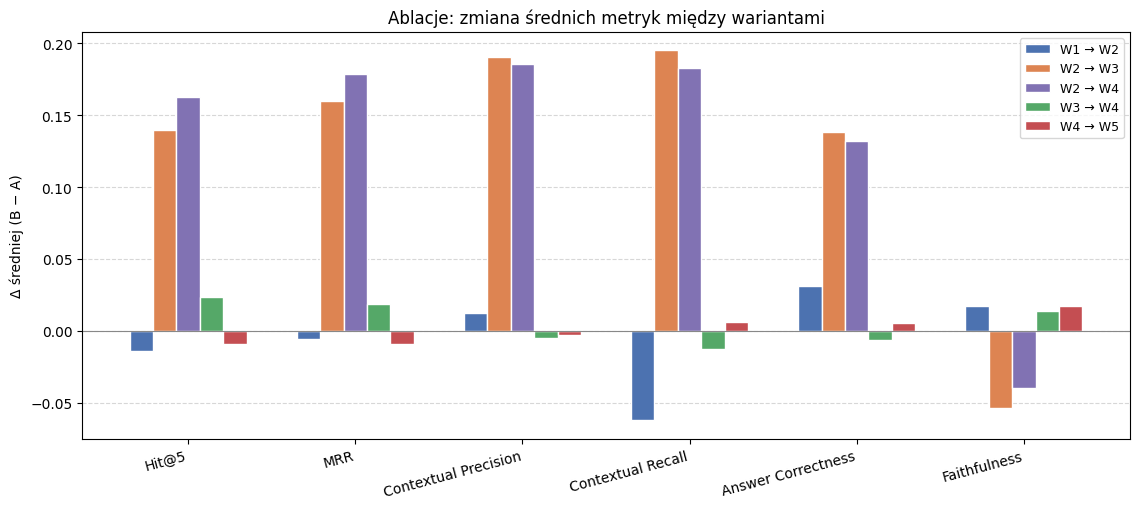

Zapisano: c:\Users\Mateusz\Desktop\Praca magisterska\scholarly\evaluation\output\deepeval\ablation\figures\01_ablation_deltas.png


In [3]:
FOCUS = ["hit_at_5", "mrr", "contextual_precision", "contextual_recall", "answer_correctness", "faithfulness"]
# bez kroku orientacyjnego W1→W4 na wykresie kroków pipeline
plot_steps = [r for r in abl_rows if r["krok"] != "W1 → W4"]
x = np.arange(len(FOCUS))
width = 0.14
colors = ["#4C72B0", "#DD8452", "#8172B3", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(11.5, 5.2), facecolor="white")
for i, row in enumerate(plot_steps):
    vals = [row[f"d_{m}"] for m in FOCUS]
    ax.bar(x + (i - 2) * width, vals, width, label=row["krok"], color=colors[i], edgecolor="white")

ax.axhline(0, color="#888888", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABEL[m] for m in FOCUS], rotation=15, ha="right")
ax.set_ylabel("Δ średniej (B − A)")
ax.set_title("Ablacje: zmiana średnich metryk między wariantami")
ax.legend(frameon=True, fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()
p = FIG / "01_ablation_deltas.png"
fig.savefig(p, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Zapisano:", p)


## A.3 Interpretacja ablacji (do pracy)


In [4]:
def fmt_d(krok: str, m: str) -> str:
    r = ablations.loc[ablations["krok"] == krok].iloc[0]
    return f"{r[f'd_{m}']:+.3f}"

w3w4 = ablations.loc[ablations["krok"] == "W3 → W4"].iloc[0]
md_txt = f"""### Werdykty ablacyjne

**W1 → W2 (chunking)**  
Δ Hit@5 = {fmt_d('W1 → W2', 'hit_at_5')}, Δ MRR = {fmt_d('W1 → W2', 'mrr')}, Δ Answer Correctness = {fmt_d('W1 → W2', 'answer_correctness')}.  
Sam parent–child **nie** jest głównym dźwignią jakości względem Naive RAG (efekt zwykle mały / mieszany). Chunk Hit@5 staje się mierzalny dopiero od W2 (W1 = 0 z konstrukcji ID).

**W2 → W3 / W2 → W4 (wejście w hybrydę + rerank)**  
To typowo **największy skok** Hit@5 / MRR / Contextual Precision & Recall / Answer Correctness.  
W2→W3: Δ Hit@5 = {fmt_d('W2 → W3', 'hit_at_5')}, Δ Correctness = {fmt_d('W2 → W3', 'answer_correctness')}.  
W2→W4: Δ Hit@5 = {fmt_d('W2 → W4', 'hit_at_5')}, Δ Correctness = {fmt_d('W2 → W4', 'answer_correctness')}.

**W3 → W4 (GIN vs BM25) — wpływ indeksu FTS**  
Przy **tej samej** hybrydzie i reranku zmieniamy tylko backend FTS.  
Δ Hit@5 = {w3w4['d_hit_at_5']:+.3f}, Δ MRR = {w3w4['d_mrr']:+.3f},  
Δ Ctx. Precision = {w3w4['d_contextual_precision']:+.3f}, Δ Ctx. Recall = {w3w4['d_contextual_recall']:+.3f},  
Δ Answer Correctness = {w3w4['d_answer_correctness']:+.3f}.  
**Wniosek deskryptywny:** różnice są zwykle **małe**; ostateczny werdykt o wpływie indeksu → Część B (Wilcoxon).

**W4 → W5 (Self-RAG)**  
Δ Hit@5 / MRR ≈ 0 (Self-RAG nie zmienia retrievalu z góry). Interesujące są metryki generatora:  
Δ Faithfulness = {fmt_d('W4 → W5', 'faithfulness')}, Δ Correctness = {fmt_d('W4 → W5', 'answer_correctness')}, Δ Answer Relevancy = {fmt_d('W4 → W5', 'answer_relevancy')}.

**W1 → W4 (skumulowane)**  
Δ Hit@5 = {fmt_d('W1 → W4', 'hit_at_5')}, Δ Correctness = {fmt_d('W1 → W4', 'answer_correctness')} — pełna ścieżka vs baseline.
"""
display(Markdown(md_txt))
(OUT / f"ablation_interpretation_{BATCH_ID}.md").write_text(md_txt, encoding="utf-8")


### Werdykty ablacyjne

**W1 → W2 (chunking)**  
Δ Hit@5 = -0.014, Δ MRR = -0.005, Δ Answer Correctness = +0.031.  
Sam parent–child **nie** jest głównym dźwignią jakości względem Naive RAG (efekt zwykle mały / mieszany). Chunk Hit@5 staje się mierzalny dopiero od W2 (W1 = 0 z konstrukcji ID).

**W2 → W3 / W2 → W4 (wejście w hybrydę + rerank)**  
To typowo **największy skok** Hit@5 / MRR / Contextual Precision & Recall / Answer Correctness.  
W2→W3: Δ Hit@5 = +0.140, Δ Correctness = +0.138.  
W2→W4: Δ Hit@5 = +0.163, Δ Correctness = +0.132.

**W3 → W4 (GIN vs BM25) — wpływ indeksu FTS**  
Przy **tej samej** hybrydzie i reranku zmieniamy tylko backend FTS.  
Δ Hit@5 = +0.023, Δ MRR = +0.019,  
Δ Ctx. Precision = -0.005, Δ Ctx. Recall = -0.013,  
Δ Answer Correctness = -0.006.  
**Wniosek deskryptywny:** różnice są zwykle **małe**; ostateczny werdykt o wpływie indeksu → Część B (Wilcoxon).

**W4 → W5 (Self-RAG)**  
Δ Hit@5 / MRR ≈ 0 (Self-RAG nie zmienia retrievalu z góry). Interesujące są metryki generatora:  
Δ Faithfulness = +0.018, Δ Correctness = +0.006, Δ Answer Relevancy = -0.001.

**W1 → W4 (skumulowane)**  
Δ Hit@5 = +0.149, Δ Correctness = +0.163 — pełna ścieżka vs baseline.


1202

# Część B — Istotność statystyczna

## B.1 Metodologia

**Jednostka analizy:** to samo pytanie Golden QA (`golden_id`) w dwóch wariantach (próba **sparowana**).

**Test:** Wilcoxon signed-rank (`scipy.stats.wilcoxon`, `zero_method="wilcox"`).

**H₀:** rozkład różnic B−A jest symetryczny wokół zera (brak systematycznej przewagi wariantu B).  
**H₁:** wariant B różni się systematycznie od A.  
**α = 0.05** (dwustronnie). Oznaczenia: `*` p<0.05, `**` p<0.01, `***` p<0.001, `ns` — brak istotności.

**Dlaczego Wilcoxon (nie t-test):** score’y RAG / LLM-judge są ograniczone do [0,1], często skośne i z remisami; test rangowy nie wymaga normalności różnic.

**Metryki:** Hit@5, MRR (z kohorty DeepEval `per_q`) oraz 5 metryk DeepEval.  
Chunk Hit@5 tylko deskryptywnie w ablacji (W1 ma 0 z konstrukcji — nie testujemy W1 na Chunk Hit@5).

**Wielokrotne porównania:** raportujemy surowe p; przy interpretacji „eksploracyjnej” wielu par × metryk traktujemy p<0.05 ostrożnie (można stosować Holm w rozszerzeniu).


## B.2 Wilcoxon — Hit@5 i MRR


In [11]:
def wilcoxon_pairs(df: pd.DataFrame, metric: str, pairs: list[tuple]) -> pd.DataFrame:
    wide = df.pivot_table(index="golden_id", columns="variant", values=metric, aggfunc="first")
    out = []
    for a, b, krok, _zmiana in pairs:
        if a not in wide.columns or b not in wide.columns:
            continue
        sub = wide[[a, b]].dropna()
        diff = sub[b] - sub[a]
        if len(sub) < 5 or (diff == 0).all():
            stat, pval = np.nan, np.nan
        else:
            try:
                res = stats.wilcoxon(sub[a], sub[b], zero_method="wilcox")
                stat, pval = float(res.statistic), float(res.pvalue)
            except ValueError:
                stat, pval = np.nan, np.nan
        out.append({
            "metric": metric,
            "krok": krok,
            "n": len(sub),
            "mean_a": float(sub[a].mean()),
            "mean_b": float(sub[b].mean()),
            "mean_diff": float(diff.mean()),
            "p_value": pval,
            "sig": (
                "***" if pd.notna(pval) and pval < 0.001 else
                "**" if pd.notna(pval) and pval < 0.01 else
                "*" if pd.notna(pval) and pval < 0.05 else
                "ns" if pd.notna(pval) else ""
            ),
        })
    return pd.DataFrame(out)


def format_wilc(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["metric"] = out["metric"].map(lambda m: METRIC_LABEL.get(m, m))
    return out.rename(columns={
        "metric": "Metryka",
        "krok": "Porównanie",
        "n": "n",
        "mean_a": "Śr. A",
        "mean_b": "Śr. B",
        "mean_diff": "Δ (B−A)",
        "p_value": "p",
        "sig": "sig",
    })


wil_ret = pd.concat(
    [wilcoxon_pairs(per_q, m, ABLATION_PAIRS) for m in ["hit_at_5", "mrr"]],
    ignore_index=True,
)
display(format_wilc(wil_ret).round(4))
wil_ret.to_csv(OUT / f"wilcoxon_retrieval_{BATCH_ID}.csv", index=False)


C:\Users\Mateusz\AppData\Local\Temp\ipykernel_32328\1302999150.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="golden_id", columns="variant", values=metric, aggfunc="first")
C:\Users\Mateusz\AppData\Local\Temp\ipykernel_32328\1302999150.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="golden_id", columns="variant", values=metric, aggfunc="first")


,Metryka,Porównanie,n,Śr. A,Śr. B,Δ (B−A),p,sig
0,Hit@5,W1 → W2,206,0.7427,0.7282,-0.0146,0.6015,ns
1,Hit@5,W2 → W3,193,0.7565,0.9326,0.1762,0.0000,***
2,Hit@5,W2 → W4,198,0.7525,0.9343,0.1818,0.0000,***
3,Hit@5,W3 → W4,189,0.9365,0.9365,0.0000,1.0000,ns
4,Hit@5,W4 → W5,195,0.9333,0.9333,0.0000,NaN,
5,Hit@5,W1 → W4,198,0.7677,0.9343,0.1667,0.0000,***
6,MRR,W1 → W2,206,0.7066,0.7011,-0.0056,0.9134,ns
7,MRR,W2 → W3,193,0.7275,0.9266,0.1991,0.0000,***
8,MRR,W2 → W4,198,0.7281,0.9234,0.1953,0.0000,***
9,MRR,W3 → W4,189,0.9303,0.9250,-0.0053,0.7928,ns


## B.3 Wilcoxon — metryki DeepEval


C:\Users\Mateusz\AppData\Local\Temp\ipykernel_32328\1302999150.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="golden_id", columns="variant", values=metric, aggfunc="first")
C:\Users\Mateusz\AppData\Local\Temp\ipykernel_32328\1302999150.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="golden_id", columns="variant", values=metric, aggfunc="first")
C:\Users\Mateusz\AppData\Local\Temp\ipykernel_32328\1302999150.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain th

,Metryka,Porównanie,n,Śr. A,Śr. B,Δ (B−A),p,sig
0,Faithfulness,W1 → W2,200,0.8279,0.8417,0.0138,0.3137,ns
1,Faithfulness,W2 → W3,185,0.8332,0.7881,-0.0452,0.0136,*
2,Faithfulness,W2 → W4,195,0.8401,0.8018,-0.0383,0.0304,*
3,Faithfulness,W3 → W4,183,0.7914,0.7993,0.0079,0.5312,ns
4,Faithfulness,W4 → W5,191,0.8039,0.8193,0.0154,0.1500,ns
5,Faithfulness,W1 → W4,195,0.8226,0.8024,-0.0202,0.3112,ns
6,Answer Relevancy,W1 → W2,205,0.8617,0.8543,-0.0075,0.6052,ns
7,Answer Relevancy,W2 → W3,193,0.8563,0.8914,0.0351,0.0952,ns
8,Answer Relevancy,W2 → W4,197,0.8496,0.9067,0.0570,0.0088,**
9,Answer Relevancy,W3 → W4,188,0.8903,0.9022,0.0119,0.3715,ns


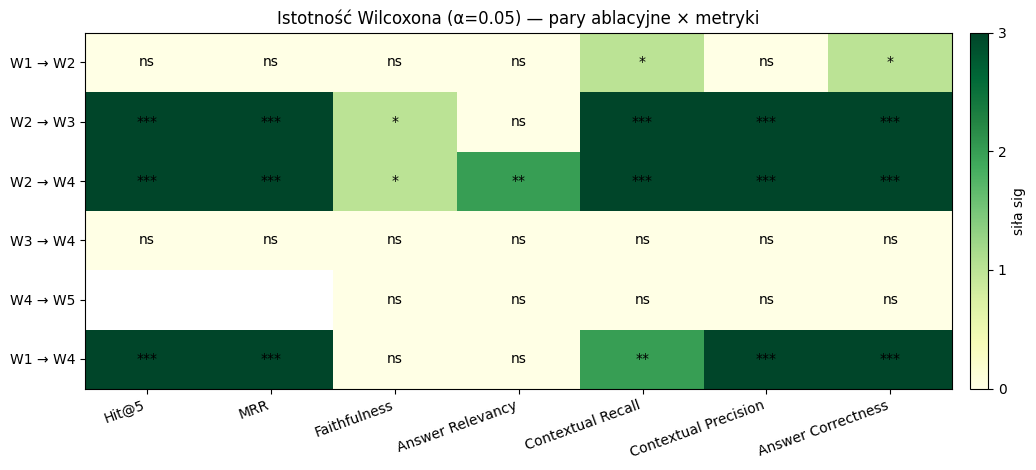

Zapisano: c:\Users\Mateusz\Desktop\Praca magisterska\scholarly\evaluation\output\deepeval\ablation\figures\02_wilcoxon_significance_heatmap.png


In [12]:
wil_de = pd.concat(
    [wilcoxon_pairs(per_q, m, ABLATION_PAIRS) for m in DE_METRICS],
    ignore_index=True,
)
display(format_wilc(wil_de).round(4))
wil_de.to_csv(OUT / f"wilcoxon_deepeval_{BATCH_ID}.csv", index=False)

# heatmap istotności: kroki × metryki
sig_map = {"***": 3, "**": 2, "*": 1, "ns": 0, "": np.nan}
order_steps = [p[2] for p in ABLATION_PAIRS]
order_metrics = ["hit_at_5", "mrr"] + DE_METRICS
heat = (
    pd.concat([wil_ret, wil_de], ignore_index=True)
    .assign(sig_n=lambda d: d["sig"].map(sig_map))
    .pivot_table(index="krok", columns="metric", values="sig_n", aggfunc="first")
    .reindex(index=order_steps, columns=order_metrics)
)

fig, ax = plt.subplots(figsize=(10.5, 4.8), facecolor="white")
im = ax.imshow(heat.to_numpy(dtype=float), aspect="auto", cmap="YlGn", vmin=0, vmax=3)
ax.set_xticks(range(len(order_metrics)))
ax.set_xticklabels([METRIC_LABEL[m] for m in order_metrics], rotation=20, ha="right")
ax.set_yticks(range(len(order_steps)))
ax.set_yticklabels(order_steps)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.isna(val):
            txt = ""
        else:
            txt = {0: "ns", 1: "*", 2: "**", 3: "***"}[int(val)]
        ax.text(j, i, txt, ha="center", va="center", fontsize=10)
ax.set_title("Istotność Wilcoxona (α=0.05) — pary ablacyjne × metryki")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, ticks=[0, 1, 2, 3], label="siła sig")
fig.tight_layout()
hp = FIG / "02_wilcoxon_significance_heatmap.png"
fig.savefig(hp, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Zapisano:", hp)


## B.3b Tabela istotności do pracy (p + sig)

Jedna tabela: wiersze = metryki (z kategorią), kolumny = kroki ablacji.  
Komórka: `p (sig)` — np. `0.601 (ns)`.  
**APA:** wartości zaokrąglone do zera zapisujemy jako `< 0.001 (***)`, nigdy `0.000`.  
Brak testu / same zera różnic → `NaN (-)`.  
Chunk Hit@5: Wilcoxon na kohorcie offline (`runs_ok_enriched`).


In [15]:
# Chunk Hit@5 z offline (pełna kohorta OK) — sparowane Wilcoxon jak wyżej
off_pq = pd.read_csv(OFF / "runs_ok_enriched.csv")
off_pq["variant"] = pd.Categorical(off_pq["variant"], categories=VARIANT_ORDER, ordered=True)
wil_chunk = wilcoxon_pairs(off_pq, "chunk_hit5", ABLATION_PAIRS)

all_sig = pd.concat([wil_ret, wil_chunk, wil_de], ignore_index=True)

STEP_ORDER = [p[2] for p in ABLATION_PAIRS]
ROW_SPEC = [
    ("Metryki wyszukiwania (Retrieval)", "hit_at_5", "Hit@5"),
    ("Metryki wyszukiwania (Retrieval)", "mrr", "MRR"),
    ("Metryki wyszukiwania (Retrieval)", "chunk_hit5", "Chunk Hit@5"),
    ("Metryki generacji (DeepEval)", "contextual_precision", "Contextual Precision"),
    ("Metryki generacji (DeepEval)", "contextual_recall", "Contextual Recall"),
    ("Metryki generacji (DeepEval)", "faithfulness", "Faithfulness"),
    ("Metryki generacji (DeepEval)", "answer_relevancy", "Answer Relevancy"),
    ("Metryki generacji (DeepEval)", "answer_correctness", "Answer Correctness"),
]


def fmt_p_sig(p, sig) -> str:
    """APA-style: nigdy '0.000' — zamiast tego '< 0.001'."""
    if pd.isna(p):
        return "NaN (-)"
    lab = sig if isinstance(sig, str) and sig else "-"
    p = float(p)
    if p < 0.001:
        return f"< 0.001 ({lab})"
    return f"{p:.3f} ({lab})"


rows = []
index_tuples = []
for cat, key, label in ROW_SPEC:
    index_tuples.append((cat, label))
    row = {}
    for krok in STEP_ORDER:
        hit = all_sig[(all_sig["metric"] == key) & (all_sig["krok"] == krok)]
        if hit.empty:
            row[krok] = "NaN (-)"
        else:
            r = hit.iloc[0]
            row[krok] = fmt_p_sig(r["p_value"], r["sig"])
    rows.append(row)

sig_table = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(index_tuples, names=["Kategoria", "Metryka"]))
display(sig_table)

sig_table.to_csv(OUT / f"significance_table_{BATCH_ID}.csv", encoding="utf-8-sig")
# Excel: MultiIndex → dwie kolumny kategorii
sig_xlsx = sig_table.reset_index()
sig_xlsx.to_excel(OUT / f"significance_table_{BATCH_ID}.xlsx", index=False)
print("CSV/XLSX:", OUT / f"significance_table_{BATCH_ID}.csv")


C:\Users\Mateusz\AppData\Local\Temp\ipykernel_32328\1302999150.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index="golden_id", columns="variant", values=metric, aggfunc="first")


W1 → W2  \
Kategoria                        Metryka                               
Metryki wyszukiwania (Retrieval) Hit@5                    0.602 (ns)   
                                 MRR                      0.913 (ns)   
                                 Chunk Hit@5           < 0.001 (***)   
Metryki generacji (DeepEval)     Contextual Precision     0.982 (ns)   
                                 Contextual Recall         0.031 (*)   
                                 Faithfulness             0.314 (ns)   
                                 Answer Relevancy         0.605 (ns)   
                                 Answer Correctness        0.026 (*)   

                                                             W2 → W3  \
Kategoria                        Metryka                               
Metryki wyszukiwania (Retrieval) Hit@5                 < 0.001 (***)   
                                 MRR                   < 0.001 (***)   
                                 Chunk Hit@5              0.001 (**)   
Metryki generacji (DeepEval)     Contextual Precision  < 0.001 (***)   
                                 Contextual Recall     < 0.001 (***)   
                                 Faithfulness              0.014 (*)   
                                 Answer Relevancy         0.095 (ns)   
                                 Answer Correctness    < 0.001 (***)   

                                                             W2 → W4  \
Kategoria                        Metryka                               
Metryki wyszukiwania (Retrieval) Hit@5                 < 0.001 (***)   
                                 MRR                   < 0.001 (***)   
                                 Chunk Hit@5              0.004 (**)   
Metryki generacji (DeepEval)     Contextual Precision  < 0.001 (***)   
                                 Contextual Recall     < 0.001 (***)   
                                 Faithfulness              0.030 (*)   
                                 Answer Relevancy         0.009 (**)   
                                 Answer Correctness    < 0.001 (***)   

                                                          W3 → W4     W4 → W5  \
Kategoria                        Metryka                                        
Metryki wyszukiwania (Retrieval) Hit@5                 1.000 (ns)     NaN (-)   
                                 MRR                   0.793 (ns)     NaN (-)   
                                 Chunk Hit@5           0.695 (ns)  0.655 (ns)   
Metryki generacji (DeepEval)     Contextual Precision  0.964 (ns)  0.562 (ns)   
                                 Contextual Recall     0.437 (ns)  0.652 (ns)   
                                 Faithfulness          0.531 (ns)  0.150 (ns)   
                                 Answer Relevancy      0.372 (ns)  0.861 (ns)   
                                 Answer Correctness    0.544 (ns)  0.959 (ns)   

                                                             W1 → W4  
Kategoria                        Metryka                              
Metryki wyszukiwania (Retrieval) Hit@5                 < 0.001 (***)  
                                 MRR                   < 0.001 (***)  
                                 Chunk Hit@5           < 0.001 (***)  
Metryki generacji (DeepEval)     Contextual Precision  < 0.001 (***)  
                                 Contextual Recall        0.002 (**)  
                                 Faithfulness             0.311 (ns)  
                                 Answer Relevancy         0.214 (ns)  
                                 Answer Correctness    < 0.001 (***)

CSV/XLSX: c:\Users\Mateusz\Desktop\Praca magisterska\scholarly\evaluation\output\deepeval\ablation\significance_table_eval-main.csv


## B.4 Focus: W3 vs W4 (wpływ indeksu GIN → BM25)


## B.5 Podsumowanie końcowe


In [8]:
all_wilc = pd.concat([wil_ret, wil_de], ignore_index=True)

def sig_steps(metric: str) -> str:
    sub = all_wilc[all_wilc["metric"] == metric]
    hits = sub.loc[sub["sig"].isin(["*", "**", "***"]), "krok"].tolist()
    return ", ".join(hits) if hits else "brak"

summary_md = f"""# Podsumowanie — ablacje + istotność (`{BATCH_ID}`)

## Ablacje (kierunek efektu)
- **W1→W2:** mały / mieszany efekt chunkingu.
- **W2→W3 oraz W2→W4:** główny skok jakości (hybryda + rerank).
- **W3→W4:** małe Δ — wpływ indeksu FTS ograniczony (szczegóły wyżej).
- **W4→W5:** retrieval bez zmian; generacja — sprawdzić Faithfulness / Correctness.

## Istotność (Wilcoxon, pary pytań, α=0.05)
- Hit@5 — istotne kroki: **{sig_steps('hit_at_5')}**
- MRR — istotne kroki: **{sig_steps('mrr')}**
- Answer Correctness — istotne kroki: **{sig_steps('answer_correctness')}**
- Contextual Precision — istotne kroki: **{sig_steps('contextual_precision')}**
- Contextual Recall — istotne kroki: **{sig_steps('contextual_recall')}**

Pliki: `{OUT.as_posix()}`
"""
display(Markdown(summary_md))
(OUT / f"SUMMARY_{BATCH_ID}.md").write_text(summary_md, encoding="utf-8")
print("OUT:", OUT)


# Podsumowanie — ablacje + istotność (`eval-main`)

## Ablacje (kierunek efektu)
- **W1→W2:** mały / mieszany efekt chunkingu.
- **W2→W3 oraz W2→W4:** główny skok jakości (hybryda + rerank).
- **W3→W4:** małe Δ — wpływ indeksu FTS ograniczony (szczegóły wyżej).
- **W4→W5:** retrieval bez zmian; generacja — sprawdzić Faithfulness / Correctness.

## Istotność (Wilcoxon, pary pytań, α=0.05)
- Hit@5 — istotne kroki: **W2 → W3, W2 → W4, W1 → W4**
- MRR — istotne kroki: **W2 → W3, W2 → W4, W1 → W4**
- Answer Correctness — istotne kroki: **W1 → W2, W2 → W3, W2 → W4, W1 → W4**
- Contextual Precision — istotne kroki: **W2 → W3, W2 → W4, W1 → W4**
- Contextual Recall — istotne kroki: **W1 → W2, W2 → W3, W2 → W4, W1 → W4**

Pliki: `c:/Users/Mateusz/Desktop/Praca magisterska/scholarly/evaluation/output/deepeval/ablation`


OUT: c:\Users\Mateusz\Desktop\Praca magisterska\scholarly\evaluation\output\deepeval\ablation
